In [1]:
#100 big12 conference games, choosing 35, less downloading
import numpy as np

sample = np.random.choice(range(1, 96), 35, replace=False)
print(sample)

[78 36 26 59 25 44 52 14  9  7  2 61 38 43 17 51 71 15 87 42 66 45 32  8
 79 76 58 80 85 95 13 28  3 67 63]


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import os

from functions import (
    compute_shot_chain_scores,
    parse_player_data_xml,
    add_team_name,
    plot_keeper_dist,
    parse_team_data_xml,
)

#Set WD - important
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_FOLDER = PROJECT_ROOT / "2025_data" / "big12_random_35_games"

In [3]:
files = [
    f for f in os.listdir(DATA_FOLDER)
    if "Team-based" in f and f.endswith(".xml")
]

team_data = parse_team_data_xml(
    folder=DATA_FOLDER,
    files=files
)

print("Rows, Columns:", team_data.shape)
display(team_data.head())

[WARN] '/Users/hungduong/Documents/UofU-Soccer-Analytics/2025_data/big12_random_35_games/Iowa State Cyclones - Kansas Jayhawks 1-3 (Team-based).xml' has no <ALL_INSTANCES>; skipping.
Rows, Columns: (41414, 21)


,match_name,ID,code,start,end,01 - Location third,02 - Location flank,03 - End location third,04 - End location flank,05 - Length,06 - Number of team events,10 - Players,11 - Start location X,12 - Start location Y,13 - Duration,14 - Formation,15 - End location X,16 - End location Y,08 - Transition,07 - Outcome,09 - xG
0,ASU Sun Devils - Texas Tech Red Raiders 2-3 (T...,1,Ball in play,2.747956,9.143513,Middle third,Center,Final third,Right flank,Short,4 or less,4. Gillard,53.0,34.0,3.0,4-3-3,80.0,68.0,NaN,NaN,NaN
1,ASU Sun Devils - Texas Tech Red Raiders 2-3 (T...,2,ASU Sun Devils - Possessions,2.747956,9.143513,Middle third,Center,Final third,Right flank,Short,4 or less,4. Gillard,53.0,34.0,3.0,4-3-3,80.0,68.0,NaN,NaN,NaN
2,ASU Sun Devils - Texas Tech Red Raiders 2-3 (T...,3,Ball in play,11.326468,18.618927,Own third,Left flank,Middle third,Left flank,Short,4 or less,"3. Bahr, 9. Parsons, 16. Zdrojewski",25.0,0.0,6.0,4-4-2,69.0,60.0,NaN,NaN,NaN
3,ASU Sun Devils - Texas Tech Red Raiders 2-3 (T...,4,Texas Tech Red Raiders - Possessions,11.326468,18.618927,Own third,Left flank,Middle third,Left flank,Short,4 or less,"3. Bahr, 9. Parsons, 16. Zdrojewski",25.0,0.0,6.0,4-4-2,69.0,60.0,NaN,NaN,NaN
4,ASU Sun Devils - Texas Tech Red Raiders 2-3 (T...,5,Texas Tech Red Raiders - Set Pieces,11.326468,18.618927,Own third,Left flank,Middle third,Left flank,Short,4 or less,"3. Bahr, 9. Parsons, 16. Zdrojewski",25.0,0.0,6.0,4-4-2,69.0,60.0,NaN,NaN,NaN


In [4]:
print(team_data['code'].unique())

['Ball in play' 'ASU Sun Devils - Possessions'
 'Texas Tech Red Raiders - Possessions'
 'Texas Tech Red Raiders - Set Pieces'
 'Texas Tech Red Raiders - Throw ins'
 'Texas Tech Red Raiders - Open play attacks'
 'Texas Tech Red Raiders - Crosses' 'Texas Tech Red Raiders - Corners'
 'ASU Sun Devils - Goalkeeper distributions'
 'Texas Tech Red Raiders - Highlights' 'Texas Tech Red Raiders - Goals'
 'Texas Tech Red Raiders - Shots' 'ASU Sun Devils - Set Pieces'
 'ASU Sun Devils - Throw ins' 'ASU Sun Devils - Free kicks'
 'Texas Tech Red Raiders - Goalkeeper distributions'
 'ASU Sun Devils - Open play attacks' 'ASU Sun Devils - Crosses'
 'ASU Sun Devils - Corners' 'ASU Sun Devils - Highlights'
 'ASU Sun Devils - Shots' 'ASU Sun Devils - Goals'
 'Texas Tech Red Raiders - Free kicks' 'Periods'
 'Cincinnati Bearcats - Possessions' 'Utah Utes - Possessions'
 'Utah Utes - Set Pieces' 'Utah Utes - Throw ins'
 'Cincinnati Bearcats - Open play attacks'
 'Cincinnati Bearcats - Set Pieces' 'Cincinnat

In [6]:
files = [
    f for f in os.listdir(DATA_FOLDER)
    if "Player-based" in f and f.endswith(".xml")
]

player_data = parse_player_data_xml(
    folder=DATA_FOLDER,
    files=files,
    numeric_cols=["ID", "Start Time", "End Time"]
)

print("Rows, Columns:", player_data.shape)
display(player_data.head())

Rows, Columns: (52653, 7)


,Source File,ID,Player Code,Start Time,End Time,Action Type,Additional Labels
0,West Virginia Mountaineers - Houston Cougars 3...,1,3. Minor,1.104223,6.104223,Pass,"Back pass, Short or medium pass"
1,West Virginia Mountaineers - Houston Cougars 3...,2,6. Shannon,2.586274,8.300127,Pass,"Lateral pass, Short or medium pass"
2,West Virginia Mountaineers - Houston Cougars 3...,3,9. Hodgson,5.300127,10.620439,Pass,"Lateral pass, Short or medium pass"
3,West Virginia Mountaineers - Houston Cougars 3...,4,12. Whitcraft,7.620439,13.912391,Pass,"Lateral pass, Short or medium pass"
4,West Virginia Mountaineers - Houston Cougars 3...,5,15. Bumba,10.912391,18.702229,Pass,Short or medium pass


In [7]:
print(player_data['Action Type'].unique())

['Pass' 'Interception' 'Throw in' 'Duel' 'Clearance' 'Touch' 'Offside'
 'Free kick' 'Corner' 'Shot' 'Goal kick' 'Shot against' 'Infraction'
 'Acceleration' None 'Goalkeeper exit' 'Penalty' 'Own goal']


In [8]:
import pandas as pd

team = team_data.copy()
player = player_data.copy()

# -----------------------------
# FIX match_id (IMPORTANT)
# -----------------------------
team["match_id"] = team["match_name"].str.replace(
    r"\s*\(Team-based\)", "", regex=True
)

player["match_id"] = player["Source File"].str.replace(
    r"\s*\(Player-based\)\.xml", "", regex=True
)

# goal rows
goals = team[team["code"].str.contains("Goals", case=False, na=False)].copy()

# passes
passes = player[player["Action Type"] == "Pass"].copy()

# merge correctly
df = goals.merge(passes, on="match_id")

# time window (with buffer)
df = df[
    (df["Start Time"] <= df["end"]) &
    (df["Start Time"] >= df["start"] - 10)
]

# last pass before goal
assists = (
    df.sort_values(["ID_x", "Start Time"])
      .groupby("ID_x")
      .tail(1)
)

# proxy coordinates
assists["assist_x"] = assists["11 - Start location X"]
assists["assist_y"] = assists["12 - Start location Y"]

print(assists[[
    "match_id",
    "Player Code",
    "Start Time",
    "assist_x",
    "assist_y"
]])

                                               match_id     Player Code  \
43925  West Virginia Mountaineers - Houston Cougars 3-2     21. Respass   
26221                      Baylor Bears - Utah Utes 2-0         4. Hess   
35123          Iowa State Cyclones - ASU Sun Devils 1-1      3. Agrusso   
55828               TCU Frogs - Iowa State Cyclones 3-1    3. Hennessey   
36426   West Virginia Mountaineers - ASU Sun Devils 2-0      4. Gillard   
...                                                 ...             ...   
21507           TCU Frogs - Oklahoma State Cowgirls 3-1   23. Coppinger   
63104                Kansas Jayhawks - Baylor Bears 0-3       9. Conrad   
15385     Oklahoma State Cowgirls - Kansas Jayhawks 0-1       18. Watts   
9886       Texas Tech Red Raiders - Kansas Jayhawks 2-0      9. Parsons   
14958                  ASU Sun Devils - BYU Cougars 2-1  8. Krommenhoek   

        Start Time  assist_x  assist_y  
43925  5449.917785      67.0      47.0  
26221  5943.44223

In [9]:
assists.head(10)

,match_name,ID_x,code,start,end,01 - Location third,02 - Location flank,03 - End location third,04 - End location flank,05 - Length,06 - Number of team events,10 - Players,11 - Start location X,12 - Start location Y,13 - Duration,14 - Formation,15 - End location X,16 - End location Y,08 - Transition,07 - Outcome,09 - xG,match_id,Source File,ID_y,Player Code,Start Time,End Time,Action Type,Additional Labels,assist_x,assist_y
43925,West Virginia Mountaineers - Houston Cougars 3...,1006,West Virginia Mountaineers - Goals,5451.765281,5460.232055,Middle third,Right flank,Final third,Center,Short,4 or less,"13. Hauer, 21. Respass, 5. White",67.0,47.0,5.0,4-2-3-1,93.0,37.0,NaN,Goal,from 0.35 to 0.66,West Virginia Mountaineers - Houston Cougars 3-2,West Virginia Mountaineers - Houston Cougars 3...,1360,21. Respass,5449.917785,5454.917785,Pass,Short or medium pass,67.0,47.0
26221,Baylor Bears - Utah Utes 2-0 (Team-based),1026,Baylor Bears - Goals,5939.899434,5951.872869,Final third,Left flank,Final third,Center,Short,5-9,"4. Hess, 11. Isgrig, 13. Obar",105.0,0.0,7.0,4-1-4-1,78.0,36.0,NaN,Goal,less than 0.1,Baylor Bears - Utah Utes 2-0,Baylor Bears - Utah Utes 2-0 (Player-based).xml,1521,4. Hess,5943.442236,5948.442236,Pass,"Lateral pass, Short or medium pass, Shot assist",105.0,0.0
35123,Iowa State Cyclones - ASU Sun Devils 1-1 (Team...,1033,Iowa State Cyclones - Goals,5600.175742,5603.175742,Final third,Right flank,Final third,Right flank,Short,4 or less,16. Spitzer,93.0,47.0,0.0,4-3-3,93.0,47.0,NaN,Goal,from 0.1 to 0.35,Iowa State Cyclones - ASU Sun Devils 1-1,Iowa State Cyclones - ASU Sun Devils 1-1 (Play...,1342,3. Agrusso,5591.794800,5597.284384,Pass,"Forward pass, Long pass, Loss, Pass to final t...",93.0,47.0
55828,TCU Frogs - Iowa State Cyclones 3-1 (Team-based),104,TCU Frogs - Goals,541.451958,561.492240,Own third,Left flank,Final third,Center,Medium,5-9,"34. Cornog, 2. S.Becerra, 3. Hennessey, 17. Pa...",32.0,11.0,16.0,4-1-4-1,89.0,43.0,NaN,Goal,from 0.1 to 0.35,TCU Frogs - Iowa State Cyclones 3-1,TCU Frogs - Iowa State Cyclones 3-1 (Player-ba...,172,3. Hennessey,550.801543,557.151002,Pass,"Assist, Forward pass, Key pass, Pass to penalt...",32.0,11.0
36426,West Virginia Mountaineers - ASU Sun Devils 2-...,1083,West Virginia Mountaineers - Goals,6029.233158,6036.361452,Middle third,Left flank,Final third,Left flank,Short,4 or less,26. Nickel,56.0,5.0,2.0,4-2-3-1,72.0,12.0,NaN,Goal,less than 0.1,West Virginia Mountaineers - ASU Sun Devils 2-0,West Virginia Mountaineers - ASU Sun Devils 2-...,1370,4. Gillard,6025.732406,6030.732406,Pass,"Loss, Short or medium pass",56.0,5.0
7425,West Virginia Mountaineers - Kansas Jayhawks 0...,1094,Kansas Jayhawks - Goals,5012.245093,5034.897385,Own third,Right flank,Final third,Center,Medium,5-9,"17. Tobin, 23. Herrema, 8. Langfelder, 7. John...",30.0,52.0,19.0,3-4-1-2,100.0,37.0,NaN,Goal,from 0.35 to 0.66,West Virginia Mountaineers - Kansas Jayhawks 0-4,West Virginia Mountaineers - Kansas Jayhawks 0...,1269,7. Johnston,5025.484334,5030.953490,Pass,"Forward pass, Second assist, Short or medium pass",30.0,52.0
8653,West Virginia Mountaineers - Kansas Jayhawks 0...,1213,Kansas Jayhawks - Goals,5666.299420,5675.577451,Own third,Center,Final third,Center,Short,4 or less,"15. Castans, 4. Wimes, 18. Watts",35.0,29.0,5.0,3-4-1-2,91.0,29.0,NaN,Goal,from 0.1 to 0.35,West Virginia Mountaineers - Kansas Jayhawks 0-4,West Virginia Mountaineers - Kansas Jayhawks 0...,1389,4. Wimes,5667.531561,5672.577451,Pass,"Assist, Deep completion, Forward pass, Head pa...",35.0,29.0
38708,Kansas State Wildcats - West Virginia Mountain...,1270,West Virginia Mountaineers - Goals,5260.244618,5297.967213,Middle third,Right flank,Final third,Right flank,Long,10-14,"21. Respass, 5. White, 6. Leoni, 12. Shertzer",46.0,52.0,33.0,4-2-3-1,91.0,46.0,NaN,Goal,less than 0.1,Kansas State Wildcats - West Virginia Mountain...,Kansas State Wildcats - West Virginia Mountain...,1351,12. Shertzer,5285.137981,5294.967213,Pass,"Assist, Cros

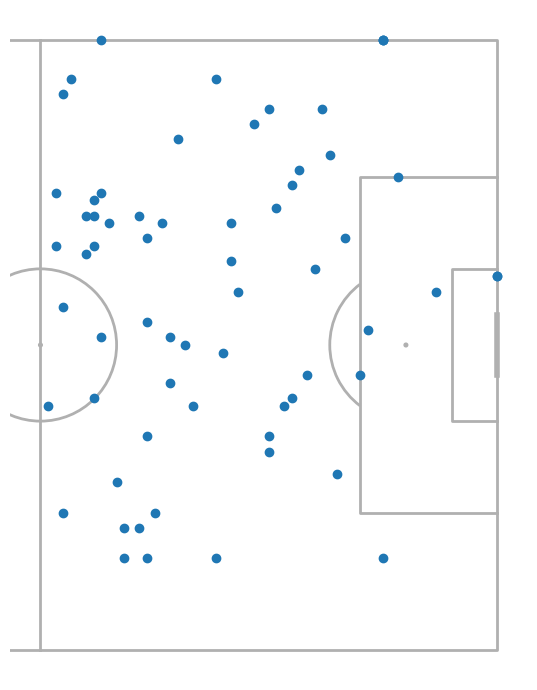

In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

df = assists.copy()

# use correct column names
df["assist_x"] = df["11 - Start location X"].apply(lambda x: 120 - x if x < 60 else x)
df["assist_y"] = df["12 - Start location Y"]

pitch = Pitch(pitch_type='statsbomb', half=True)
fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(df["assist_x"], df["assist_y"], ax=ax)

plt.show()

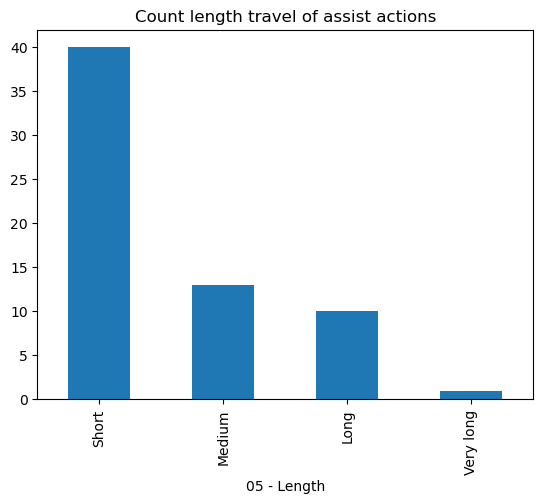

In [11]:
# Distant of assist ball action
assists["05 - Length"].value_counts().plot(kind="bar")
plt.title('Count length travel of assist actions')
plt.show()

In [12]:
assists["Additional Labels"].unique()

array(['Short or medium pass',
       'Lateral pass, Short or medium pass, Shot assist',
       'Forward pass, Long pass, Loss, Pass to final third',
       'Assist, Forward pass, Key pass, Pass to penalty area, Progressive pass, Short or medium pass, Shot assist',
       'Loss, Short or medium pass',
       'Forward pass, Second assist, Short or medium pass',
       'Assist, Deep completion, Forward pass, Head pass, Key pass, Pass to penalty area, Progressive pass, Short or medium pass, Shot assist',
       'Assist, Cross, Deep completed cross, Key pass, Lateral pass, Pass to penalty area, Shot assist',
       'Forward pass, Second assist, Progressive pass, Short or medium pass',
       'Assist, Deep completion, Forward pass, Key pass, Pass to penalty area, Progressive pass, Short or medium pass, Shot assist, Smart pass, Through pass',
       'Cross, Cross blocked',
       'Assist, Back pass, Key pass, Short or medium pass, Shot assist, Touch in box',
       'Assist, Deep completion, 

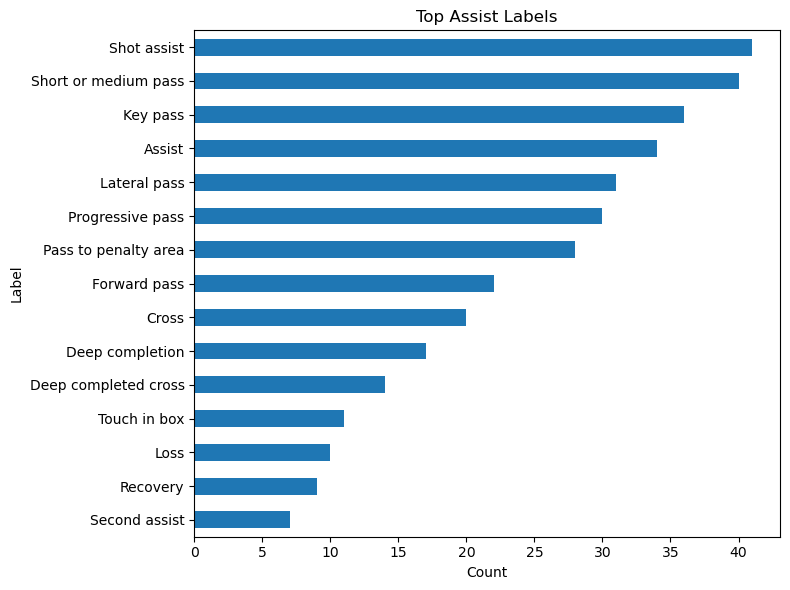

In [13]:

# Split → explode → count
freq = (
    assists["Additional Labels"]
    .str.split(", ")
    .explode()
    .value_counts()
)

# Plot (top 15 for readability)
freq.head(15).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top Assist Labels")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

# Analysis